# Resource estimation for SOSSA sum-of-squares spectral amplification

This notebook estimates the cost of running **unary-iteration quantum phase estimation** on a
Hamiltonian block-encoded with **SOSSA** (sum-of-squares spectral amplification, Low *et al.*,
[arXiv:2502.15882](https://arxiv.org/abs/2502.15882)).

SOSSA writes an electronic-structure Hamiltonian as a shifted sum of squares,

$$
H \;=\; \underbrace{\sum_{x} c_x\, A_x^{\dagger} A_x}_{H_{\mathrm{gap}} \;\succeq\; 0} \;+\; E_{\mathrm{SOS}},
$$

where every generator $A_x$ is a Majorana bilinear drawn from a double-factorized (DFTHC)
representation of the two-body integrals. Because $H_{\mathrm{gap}}$ is positive semi-definite,
its ground state sits at the *edge* of the walk operator's spectral band, and the phase-to-energy
map

$$
E_{\mathrm{gap}}(\varphi) \;=\; 2\Lambda \cos^{2}(\pi\varphi)
$$

is quadratically flat there. That flatness is the amplification: a phase resolved to
$\delta\varphi \sim 1/T$ yields an energy resolved to $\delta E \sim 1/T^{2}$, so the query count
needed for a target precision scales far better than for a plain qubitization walk.

We run the full pipeline twice:

1. **Part 1 --- a stored DFTHC instance.** A small H<sub>2</sub> Hamiltonian loaded straight from
   JSON, already in the factorized form SOSSA consumes, with a non-zero `energy_gap` so the
   amplified walk is exercised.
2. **Part 2 --- stretched N<sub>2</sub>, built from scratch.** SCF, orbital localization,
   automated active-space selection, then a **double factorization** of the active-space
   two-body integrals to produce the SOSSA input.

Both parts end in the same place: a unary-iteration QPE circuit, its logical gate counts, and a
physical resource estimate from `qdk.qre`.

In addition to [installing `qdk-chemistry`](https://github.com/microsoft/qdk-chemistry/blob/main/INSTALL.md),
you will need the `qre`, `jupyter` and `qiskit-extras` extras:

```bash
pip install 'qdk-chemistry[jupyter,qiskit-extras,qre]'
```

In [10]:
import math
from pathlib import Path

import pandas as pd

from qdk_chemistry.algorithms import create
from qdk_chemistry.data import (
    AlgorithmRef,
    Configuration,
    Hamiltonian,
    MajoranaMapping,
    StateVectorContainer,
    Wavefunction,
)
from qdk_chemistry.utils import Logger

# Reduce logging output for the demo
Logger.set_global_level(Logger.LogLevel.off)

## The shared pipeline

Both halves of the notebook funnel into the same three steps, so we define them once.

`SOSSAQubitMapper` turns a `FactorizedHamiltonianContainer` into a structured qubit operator that
records the generator coefficients and scalar shift $E_{\mathrm{SOS}}$. `SOSSABuilder` derives the
generator one-norms and block-encoding normalization $\Lambda$, then the unary-iteration QPE builder
consumes the operator directly: it allocates one phase qubit per query and reuses a single controlled
walk across every slot.

The circuit-mapper settings choose how each piece of the walk is synthesized:

- `outer_prepare` --- prepares $\sqrt{c_x}$-weighted amplitudes over the generator index. Alias
  sampling gives a gate count that grows linearly rather than exponentially in the register width.
- `inner_prepare_algorithm` --- the controlled rotation cascade that builds each Majorana bilinear.
- `select_algorithm` --- `qrom_phase_gradient` applies the basis rotations through a QROM lookup
  into a shared phase-gradient register, which trades rotation synthesis for Toffolis.
- `rotation_bit_precision` / `coefficient_bit_precision` --- how finely the Givens angles and the
  amplitudes are discretized. These dominate the T/Toffoli count, so they are the main knobs to
  sweep when tightening a resource estimate.

In [11]:
def sossa_unary_qpe_circuit(
    hamiltonian,
    *,
    num_queries,
    n_alpha,
    n_beta,
    circuit_mapper=None,
    rotation_bit_precision=15,
    coefficient_bit_precision=11,
):
    """Build a unary-iteration QPE circuit driven by the SOSSA walk.

    Args:
        hamiltonian: A Hamiltonian backed by a FactorizedHamiltonianContainer.
        num_queries: Number of walk applications in the phase-estimation schedule.
        n_alpha: Number of alpha electrons in the reference determinant.
        n_beta: Number of beta electrons in the reference determinant.
        circuit_mapper: Optional SOSSA circuit mapper; defaults to the resource-estimation configuration.
        rotation_bit_precision: Bits used to discretize the Givens rotation angles.
        coefficient_bit_precision: Bits used to discretize the PREPARE amplitudes.

    Returns:
        A tuple of (QPE circuit, SOSSA qubit operator).

    """
    container = hamiltonian.get_container()
    num_orbitals = container.get_num_orbitals()
    orbitals = container.get_orbitals()

    operator = create("qubit_mapper", "sossa").run(
        hamiltonian, MajoranaMapping.jordan_wigner(2 * num_orbitals)
    )

    # Hartree-Fock reference determinant, loaded with the sparse isometry method.
    hf_config = Configuration.canonical_hf_configuration(n_alpha, n_beta, num_orbitals)
    reference = Wavefunction(StateVectorContainer(hf_config, orbitals))
    state_prep = create("state_prep", "sparse_isometry").run(reference)

    if circuit_mapper is None:
        circuit_mapper = AlgorithmRef(
            "circuit_mapper",
            "sossa",
            outer_prepare=AlgorithmRef("state_prep", "alias_sampling"),
            inner_prepare_algorithm="controlled_alias_sampling",
            select_algorithm="qrom_phase_gradient",
            rotation_bit_precision=rotation_bit_precision,
            coefficient_bit_precision=coefficient_bit_precision,
        )

    builder = create(
        "qpe_circuit_builder",
        "qdk_unary",
        num_queries=num_queries,
        circuit_mapper=circuit_mapper,
        unitary_builder=AlgorithmRef("hamiltonian_unitary_builder", "sossa"),
    )
    circuit = builder.run(state_preparation=state_prep, qubit_hamiltonian=operator)[0]
    return circuit, operator


def heisenberg_queries(lambda_sos, target_precision):
    """Queries needed to resolve ``target_precision`` at the amplified band edge.

    The unary schedule wants ``num_queries + 1`` to be a power of two, so round up.
    """
    ideal = math.pi * lambda_sos / (2.0 * target_precision)
    return 2 ** math.ceil(math.log2(max(ideal, 2.0))) - 1


def logical_counts_frame(circuit, label):
    """Return the circuit's logical resource counts as a one-column frame."""
    counts = circuit.estimate().logical_counts
    return pd.DataFrame(counts.items(), columns=["Logical Estimate", label]).set_index("Logical Estimate")

> **On the sum-of-squares precondition.** `SOSSAQubitMapper` requires every per-rank sign of the
> factorization to be non-negative --- that is what makes the decomposition a genuine *sum of
> squares* and hence $H_{\mathrm{gap}} \succeq 0$. The mapper validates this condition before
> constructing the qubit operator. For a factorization of a true electron-repulsion integral tensor
> every sign should be positive, because the ERI supermatrix is a Coulomb Gram matrix and therefore
> positive semi-definite.

## Part 1 --- a stored DFTHC Hamiltonian

The first instance ships with the repository as a serialized `FactorizedHamiltonianContainer`.
It is a minimal H<sub>2</sub> problem, $N = 2$ spatial orbitals with $R = 1$ rank, $B = 2$ bases
and $C = 1$ copy, and it carries a non-zero `energy_gap`, which is the spectral-amplification
parameter: the walk is built to amplify around that gap rather than around the raw band.

In [12]:
json_path = Path("data") / "h2_factorized_r1_b2_c1.hamiltonian.json"
h2_hamiltonian = Hamiltonian.from_json(json_path.read_text())
h2_container = h2_hamiltonian.get_container()

print(h2_hamiltonian.get_summary())

Hamiltonian Summary:
  Type: Hermitian
  Restrictedness: Restricted
  Active Orbitals: 2
  Total Orbitals: 2
  Core Energy: 0.000000
  Integral Statistics:
    One-body Integrals (alpha): 4 (larger than 0.000001: 2)
    Two-body Integrals (aaaa): 16 (larger than 0.000001: 1)



### Mapping to the SOSSA qubit operator

The mapper reads the factorization and emits the generator list together with $E_{\mathrm{SOS}}$, the
scalar that converts an $H_{\mathrm{gap}}$ eigenvalue back into a physical energy. The unitary builder
then derives $\Lambda$, half the sum of squared generator one-norms, which sets the block-encoding
normalization.

In [13]:
h2_operator = create("qubit_mapper", "sossa").run(
    h2_hamiltonian, MajoranaMapping.jordan_wigner(2 * h2_container.get_num_orbitals())
)
h2_metadata = create("hamiltonian_unitary_builder", "sossa").run(h2_operator).get_container().metadata

print(f"Block-encoding normalization  Lambda = {h2_metadata.normalization:.6f} Hartree")
print(f"Sum-of-squares shift         E_SOS  = {h2_metadata.energy_shift:.6f} Hartree")
print(f"System qubits                       = {h2_operator.get_container().num_qubits}")

Block-encoding normalization  Lambda = 0.397479 Hartree
Sum-of-squares shift         E_SOS  = -0.101608 Hartree
System qubits                       = 4


### Choosing the query schedule and sampling the circuit

Unary-iteration QPE applies the walk `num_queries` times and reads the phase off a register of
the same width. To resolve an energy $\sigma_E$ at the amplified band edge we need roughly
$\pi \Lambda / (2\sigma_E)$ queries; we round up to the next power of two minus one so the
schedule divides evenly.

The full-precision circuit is intended for resource estimation rather than local simulation. Before
estimating it, we sample a compact 7-query circuit using exact dense/direct synthesis, which avoids
the large alias-sampling and phase-gradient work registers while exercising the same SOSSA walk.

In [14]:
from qdk.widgets import Histogram

TARGET_PRECISION = 1e-3  # Hartree ("chemical accuracy" is ~1.6e-3)
h2_queries = heisenberg_queries(h2_metadata.normalization, TARGET_PRECISION)
print(f"Queries for {TARGET_PRECISION:.0e} Ha at Lambda = {h2_metadata.normalization:.4f}: {h2_queries}")

SIMULATION_QUERIES = 7
SIMULATION_SHOTS = 256
simulation_mapper = AlgorithmRef(
    "circuit_mapper",
    "sossa",
    outer_prepare=AlgorithmRef("state_prep", "dense_pure_state"),
    inner_prepare_algorithm="direct",
    select_algorithm="direct",
)
h2_simulation_circuit, _ = sossa_unary_qpe_circuit(
    h2_hamiltonian,
    num_queries=SIMULATION_QUERIES,
    n_alpha=1,
    n_beta=1,
    circuit_mapper=simulation_mapper,
)
h2_execution = create("circuit_executor", "qdk_sparse_state_simulator", seed=20250815).run(
    h2_simulation_circuit,
    shots=SIMULATION_SHOTS,
)
h2_phase_probabilities = {
    bitstring: count / h2_execution.total_shots
    for bitstring, count in h2_execution.bitstring_counts.items()
}
display(Histogram(bar_values=h2_phase_probabilities, sort="high-to-low"))

Queries for 1e-03 Ha at Lambda = 0.3975: 1023


### Logical resource estimate

Now build the full 1023-query circuit with alias-sampling PREPARE and phase-gradient SELECT, then
count its logical resources without simulating its enlarged work registers.

In [15]:
h2_circuit, _ = sossa_unary_qpe_circuit(
    h2_hamiltonian,
    num_queries=h2_queries,
    n_alpha=1,
    n_beta=1,
)
h2_counts = logical_counts_frame(h2_circuit, "H2 SOSSA unary QPE")
display(h2_counts)

,H2 SOSSA unary QPE
Logical Estimate,
numQubits,131
tCount,111
rotationCount,13465
rotationDepth,12946
cczCount,304895
ccixCount,0
measurementCount,279330


### Physical resource estimates

`qdk.qre` maps the logical circuit onto a fault-tolerant architecture and returns the
Pareto-optimal trade-offs between physical qubit count and runtime. We use a Majorana-based
architecture at a $10^{-5}$ physical error rate with the `ThreeAux` code and round-based magic
state factories, and budget 1% total error.

,name,qubits,runtime,error,factories
0,SOSSA_H2,79768,0 days 00:00:55.174353,0.008759,10×T
1,SOSSA_H2,84296,0 days 00:00:45.271264,0.008559,12×T


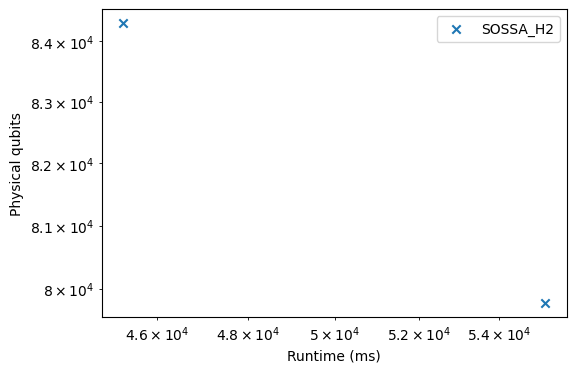

In [16]:
from qdk.qre import estimate, plot_estimates
from qdk.qre.models import Majorana, RoundBasedFactory, ThreeAux

architecture = Majorana(error_rate=1e-5)
isa_query = ThreeAux.q() * RoundBasedFactory.q(use_cache=True, code_query=ThreeAux.q())

h2_results = estimate(
    h2_circuit.get_qre_application(), architecture, isa_query, max_error=0.01, name="SOSSA_H2"
)
h2_results.add_factory_summary_column()
display(h2_results.as_frame())

plot_estimates(h2_results, figsize=(6, 4), runtime_unit="ms")

## Part 2 --- stretched N<sub>2</sub> from a structure file

The second instance is built end to end. Stretching the N<sub>2</sub> bond introduces strong
multi-reference character, which is exactly the regime where a classical single-reference method
struggles and phase estimation is interesting.

The route to a SOSSA-ready Hamiltonian is:
SCF $\rightarrow$ valence space $\rightarrow$ MP2 natural-orbital localization $\rightarrow$
autoCAS-EOS active-space selection $\rightarrow$ active-space Hamiltonian $\rightarrow$
**double factorization**.

In [17]:
from qdk_chemistry.data import Structure
from qdk_chemistry.data.symmetry import SymmetryLabel, axes

# Stretched N2 structure at 1.270025 Angstrom bond length
structure = Structure.from_xyz_file(Path("data/stretched_n2.structure.xyz"))

scf_solver = create("scf_solver")
E_hf, wfn_hf = scf_solver.run(
    structure,
    charge=0,
    spin_multiplicity=1,
    basis_or_guess="cc-pvdz",
)
print(f"Hartree-Fock energy: {E_hf:.6f} Hartree")

Hartree-Fock energy: -108.866811 Hartree


In [18]:
from qdk_chemistry.utils import compute_valence_space_parameters

# Restrict to the valence space, then localize with MP2 natural orbitals
num_val_e, num_val_o = compute_valence_space_parameters(wfn_hf, charge=0)
active_space_selector = create(
    "active_space_selector",
    "qdk_valence",
    num_active_electrons=num_val_e,
    num_active_orbitals=num_val_o,
)
valence_wf = active_space_selector.run(wfn_hf)

localizer = create("orbital_localizer", "qdk_mp2_natural_orbitals")
valence_indices = valence_wf.get_orbitals().active_indices()
loc_wfn = localizer.run(
    valence_wf,
    list(valence_indices.indices(SymmetryLabel([axes.alpha()]))),
    list(valence_indices.indices(SymmetryLabel([axes.beta()]))),
)
print(f"Valence space: {num_val_e} electrons in {num_val_o} orbitals")

Valence space: 10 electrons in 8 orbitals


/tmp/ipykernel_60757/1250860247.py:13: DeprecationWarning: MP2NaturalOrbitalLocalizer is deprecated; use NaturalOrbitalLocalizer (qdk_natural_orbitals) with a wavefunction that already contains the MP2 active-space 1-RDM.
  localizer = create("orbital_localizer", "qdk_mp2_natural_orbitals")


In [19]:
# Selected-CI wavefunction on the localized orbitals, used to drive active-space selection
hamiltonian_constructor = create("hamiltonian_constructor")
loc_hamiltonian = hamiltonian_constructor.run(loc_wfn.get_orbitals())
num_alpha_electrons, num_beta_electrons = loc_wfn.get_active_num_electrons()

macis_mc = create(
    "multi_configuration_calculator",
    "macis_asci",
    calculate_one_rdm=True,
    calculate_two_rdm=True,
)
_, wfn_sci = macis_mc.run(loc_hamiltonian, num_alpha_electrons, num_beta_electrons)

# Entropy-based active space selection
autocas = create("active_space_selector", "qdk_autocas_eos")
autocas_wfn = autocas.run(wfn_sci)
indices = list(autocas_wfn.get_orbitals().active_indices().indices(SymmetryLabel([axes.alpha()])))
print(f"autoCAS-EOS selected {len(indices)} of {num_val_o} orbitals: indices={indices}")

autoCAS-EOS selected 4 of 8 orbitals: indices=[5, 6, 7, 8]


In [20]:
# Active-space Hamiltonian, plus a CASCI reference energy to benchmark against
refined_orbitals = autocas_wfn.get_orbitals()
active_hamiltonian = hamiltonian_constructor.run(refined_orbitals)

alpha_electrons, beta_electrons = autocas_wfn.get_active_num_electrons()
mc = create("multi_configuration_calculator", "macis_cas")
e_cas, wfn_cas = mc.run(active_hamiltonian, alpha_electrons, beta_electrons)
print(f"Active space CASCI energy: {e_cas:.6f} Hartree")
print(f"Active space: {alpha_electrons} alpha + {beta_electrons} beta electrons")

Active space CASCI energy: -108.964620 Hartree
Active space: 2 alpha + 2 beta electrons


### Double factorization

SOSSA consumes a `FactorizedHamiltonianContainer`, so the active-space two-body integrals have to
be decomposed first. The eigen-decomposition factorizer diagonalizes the ERI supermatrix and keeps
the ranks above `truncation_threshold`.

We set the threshold to $10^{-8}$ rather than leaving it at the default $10^{-12}$ for two
reasons. It keeps $R$ --- and therefore the walk's PREPARE register and gate count --- small at a
cost far below chemical accuracy; and it discards the round-off-scale eigenvalues whose sign is
numerically meaningless, which is what keeps the sum-of-squares precondition clean.

In [21]:
factorizer = create("double_factorizer", "eigen_decomposition")
factorizer.settings().set("truncation_threshold", 1e-8)
n2_hamiltonian = factorizer.run(active_hamiltonian)
n2_container = n2_hamiltonian.get_container()

print(n2_hamiltonian.get_summary())

Hamiltonian Summary:
  Type: Hermitian
  Restrictedness: Restricted
  Active Orbitals: 4
  Total Orbitals: 28
  Core Energy: -103.696650
  Integral Statistics:
    One-body Integrals (alpha): 16 (larger than 0.000001: 4)
    Two-body Integrals (aaaa): 256 (larger than 0.000001: 112)



Note the contrast with Part 1: the double factorizer emits `energy_gap = 0`, so this walk is *not*
spectrally amplified around a known gap. Supplying a gap estimate --- for instance from the CASCI
solve above, or from a cheaper correlated method --- is what unlocks the amplified query scaling
on a freshly factorized Hamiltonian.

In [22]:
n2_operator = create("qubit_mapper", "sossa").run(
    n2_hamiltonian, MajoranaMapping.jordan_wigner(2 * n2_container.get_num_orbitals())
)
n2_metadata = create("hamiltonian_unitary_builder", "sossa").run(n2_operator).get_container().metadata

print(f"Block-encoding normalization  Lambda = {n2_metadata.normalization:.6f} Hartree")
print(f"Sum-of-squares shift         E_SOS  = {n2_metadata.energy_shift:.6f} Hartree")
print(f"System qubits                       = {n2_operator.get_container().num_qubits}")

Block-encoding normalization  Lambda = 3.821348 Hartree
Sum-of-squares shift         E_SOS  = -109.637639 Hartree
System qubits                       = 8


### Building the N<sub>2</sub> circuit

$\Lambda$ is much larger here than for H<sub>2</sub>, so a full Heisenberg-limited schedule would
need a correspondingly larger query count. `DEMO_QUERY_CAP` keeps the notebook interactive; raise
or remove it to estimate the cost of a production-precision run.

In [23]:
DEMO_QUERY_CAP = 255

n2_ideal_queries = heisenberg_queries(n2_metadata.normalization, TARGET_PRECISION)
n2_queries = min(n2_ideal_queries, DEMO_QUERY_CAP)
print(f"Heisenberg-limited queries for {TARGET_PRECISION:.0e} Ha: {n2_ideal_queries}")
print(f"Using {n2_queries} queries for this demo")

n2_circuit, _ = sossa_unary_qpe_circuit(
    n2_hamiltonian,
    num_queries=n2_queries,
    n_alpha=alpha_electrons,
    n_beta=beta_electrons,
)
n2_counts = logical_counts_frame(n2_circuit, "N2 SOSSA unary QPE")
display(n2_counts)

Heisenberg-limited queries for 1e-03 Ha: 8191
Using 255 queries for this demo


,N2 SOSSA unary QPE
Logical Estimate,
numQubits,171
tCount,105
rotationCount,3806
rotationDepth,3300
cczCount,395296
ccixCount,0
measurementCount,340479


,name,qubits,runtime,error,factories
0,SOSSA_N2,95980,0 days 00:01:01.611342,0.009479,10×T
1,SOSSA_N2,100508,0 days 00:00:50.552896,0.009193,12×T


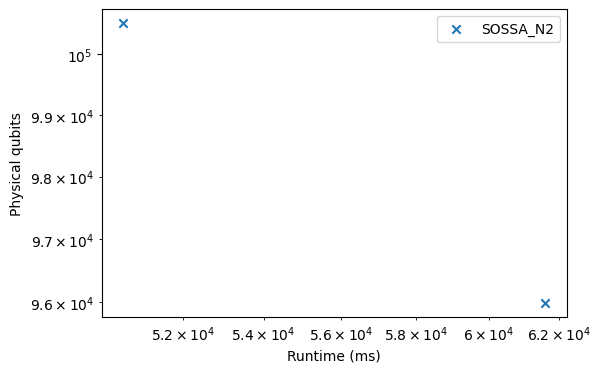

In [24]:
n2_results = estimate(
    n2_circuit.get_qre_application(), architecture, isa_query, max_error=0.01, name="SOSSA_N2"
)
n2_results.add_factory_summary_column()
display(n2_results.as_frame())

plot_estimates(n2_results, figsize=(6, 4), runtime_unit="ms")

## Comparing the two instances

The logical counts put the two problems side by side. The dominant scaling levers are the
factorization shape $(N, R, B, C)$, which sets how much data the walk's PREPARE and SELECT must
load, and the bit precisions, which set how expensive each rotation is.

In [25]:
comparison = pd.concat([h2_counts, n2_counts], axis=1)
display(comparison)

summary = pd.DataFrame(
    {
        "H2 (from JSON)": {
            "spatial orbitals (N)": h2_container.get_num_orbitals(),
            "ranks (R)": h2_container.get_num_ranks(),
            "lambda (Hartree)": round(h2_metadata.normalization, 6),
            "energy_gap (Hartree)": h2_container.get_energy_gap(),
            "queries": h2_queries,
        },
        "N2 (double factorized)": {
            "spatial orbitals (N)": n2_container.get_num_orbitals(),
            "ranks (R)": n2_container.get_num_ranks(),
            "lambda (Hartree)": round(n2_metadata.normalization, 6),
            "energy_gap (Hartree)": n2_container.get_energy_gap(),
            "queries": n2_queries,
        },
    }
)
display(summary)

,H2 SOSSA unary QPE,N2 SOSSA unary QPE
Logical Estimate,,
numQubits,131,171
tCount,111,105
rotationCount,13465,3806
rotationDepth,12946,3300
cczCount,304895,395296
ccixCount,0,0
measurementCount,279330,340479


,H2 (from JSON),N2 (double factorized)
spatial orbitals (N),2.000000,4.000000
ranks (R),1.000000,9.000000
lambda (Hartree),0.397479,3.821348
energy_gap (Hartree),0.500000,0.000000
queries,1023.000000,255.000000


## Table 4 synthetic systems

To compare the SOSSA resource scaling reported by Low *et al.* (2025), we now estimate the five
instances from their Table 4. Each instance uses a deterministic synthetic factorized Hamiltonian with
the published shape $(N,R,B,C)$; the tensor values are not molecular data, but the traced circuit cost
depends on the shape and synthesis precisions rather than those values.

For each system, the exact unary-iteration query count is

$$
p = \left\lceil \frac{\pi\lambda_{\mathrm{eff}}}{2\sigma_E} \right\rceil,
\qquad \sigma_E = 10^{-3}\ \mathrm{Ha}.
$$

The physical estimates reuse the Majorana architecture, `ThreeAux` code, round-based factories, and
1% error budget defined above.

In [26]:
import numpy as np
from qdk_chemistry.data import FactorizedHamiltonianContainer, ModelOrbitals

# The five instances from Low et al. (2025), Table 4.
MOLECULES = {
    "Fe2S2-20": dict(N=20, R=14, B=15, C=5, b_rot=15, b_coeff=11, lambda_eff=6.4690),
    "Fe4S4-36": dict(N=36, R=9, B=18, C=18, b_rot=17, b_coeff=13, lambda_eff=14.9842),
    "FeMoCo-54": dict(N=54, R=10, B=27, C=27, b_rot=15, b_coeff=15, lambda_eff=21.4486),
    "FeMoCo-76": dict(N=76, R=15, B=57, C=19, b_rot=15, b_coeff=9, lambda_eff=43.6538),
    "XVIII-56": dict(N=56, R=5, B=28, C=28, b_rot=12, b_coeff=7, lambda_eff=17.0712),
}

SIGMA_E = 1e-3  # Hartree


def make_fake_factorized_hamiltonian(
    num_orbitals: int,
    num_ranks: int,
    num_bases: int,
    num_copies: int,
    seed: int = 42,
) -> FactorizedHamiltonianContainer:
    """Build a deterministic synthetic factorized Hamiltonian with the requested shape."""
    rng = np.random.default_rng(seed)
    one_body = rng.standard_normal((num_orbitals, num_orbitals))
    one_body = (one_body + one_body.T) / 2

    basis_vectors = rng.standard_normal((num_ranks, num_bases, num_orbitals))
    basis_vectors /= np.linalg.norm(basis_vectors, axis=-1, keepdims=True)

    return FactorizedHamiltonianContainer(
        0.0,
        basis_vectors.ravel(),
        rng.standard_normal((num_ranks, num_bases, num_copies)).ravel() * 0.1,
        rng.standard_normal((num_ranks, num_copies)) * 0.1,
        one_body,
        np.zeros_like(one_body),
        ModelOrbitals(num_orbitals),
    )

In [27]:
table4_queries = {}
table4_circuits = {}

for name, params in MOLECULES.items():
    num_orbitals = int(params["N"])
    num_queries = math.ceil(math.pi * float(params["lambda_eff"]) / (2 * SIGMA_E))
    fake_hamiltonian = Hamiltonian(
        make_fake_factorized_hamiltonian(
            num_orbitals,
            int(params["R"]),
            int(params["B"]),
            int(params["C"]),
        )
    )
    reference_electrons_per_spin = num_orbitals // 2
    circuit, _ = sossa_unary_qpe_circuit(
        fake_hamiltonian,
        num_queries=num_queries,
        n_alpha=reference_electrons_per_spin,
        n_beta=reference_electrons_per_spin,
        rotation_bit_precision=int(params["b_rot"]),
        coefficient_bit_precision=int(params["b_coeff"]),
    )
    table4_queries[name] = num_queries
    table4_circuits[name] = circuit

table4_instances = pd.DataFrame.from_dict(MOLECULES, orient="index")
table4_instances["queries"] = pd.Series(table4_queries)
table4_instances.index.name = "System"
display(table4_instances)

,N,R,B,C,b_rot,b_coeff,lambda_eff,queries
System,,,,,,,,
Fe2S2-20,20,14,15,5,15,11,6.4690,10162
Fe4S4-36,36,9,18,18,17,13,14.9842,23538
FeMoCo-54,54,10,27,27,15,15,21.4486,33692
FeMoCo-76,76,15,57,19,15,9,43.6538,68572
XVIII-56,56,5,28,28,12,7,17.0712,26816


### Logical resource estimates

The circuits below use each instance's published rotation and coefficient precisions. Their logical
counts are retained as plain dictionaries so physical estimation can reuse them without retracing the
large unary schedules.

table4_logical_counts = {}

for name, circuit in table4_circuits.items():
    logical_counts = circuit.estimate().logical_counts
    table4_logical_counts[name] = {key: int(value) for key, value in logical_counts.items()}

table4_logical_counts_frame = pd.DataFrame(table4_logical_counts)
table4_logical_counts_frame.index.name = "Logical estimate"
display(table4_logical_counts_frame)